In [1]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.utils import plot_iv_surface, repair_edges_local_directional, jitter_grid, plot_param_error_ecdfs, plot_param_true_vs_est
from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=2)
surfaces = generate_surfaces(
    num_sets=1,
    forward_curves_per_set=1,
    cfg=cfg,
    seed=4235,
    randomize_grid=False,
)


=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   2.781 s
dB computation        :   0.278 s
Y computation (fBM)   :   1.466 s
TOTAL setup           :   4.525 s

=== Diagnostics for seed 400 ===
Simulator setup:       4.525 s
Xi0 mapping:           0.001 s
Path generation:       1.436 s
CMC integrals:         0.480 s
IV extraction total:   0.545 s (of which Brent inversions ≈   0.105 s)
TOTAL runtime:         6.987 s


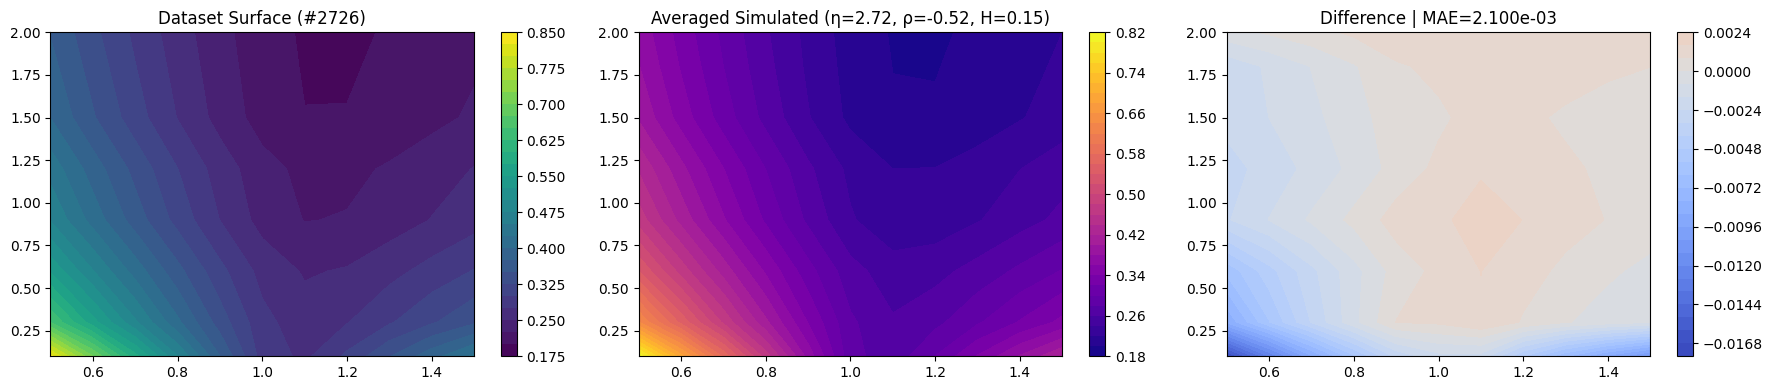

Comparison summary (averaged over seeds):
Idx 2726 | η=2.721, ρ=-0.516, H=0.148 | MAE=2.100e-03


In [1]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 1        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(1234678)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


In [ ]:

=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   2.890 s
dB computation        :   0.264 s
Y computation (fBM)   :   1.446 s
TOTAL setup           :   4.600 s

=== Diagnostics for seed 400 ===
Simulator setup:       4.601 s
Xi0 mapping:           0.000 s
Path generation:       1.395 s
CMC integrals:         0.502 s
IV extraction total:   0.600 s (of which Brent inversions ≈   0.091 s)
TOTAL runtime:         7.098 s